In [ ]:
"""
Gradient Descent is an optimization algorithm used to minimize the error of a machine learning model by updating parameters
 in the direction of decreasing loss.
"""

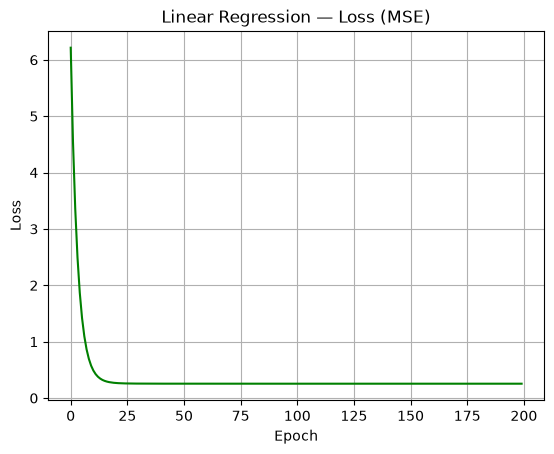

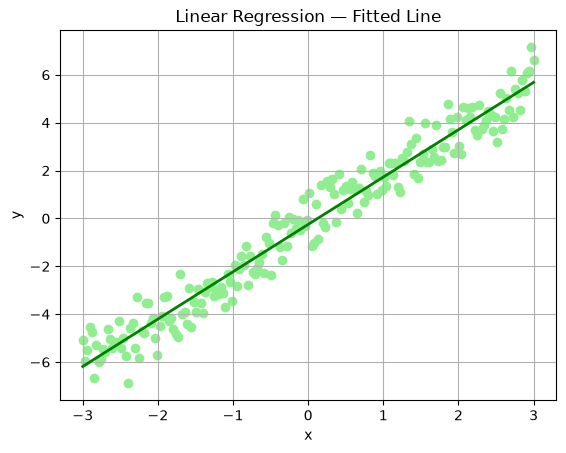

In [ ]:
# Linear Regression
# Linear Regression is a supervised learning algorithm used to predict continuous numerical values by modeling the relationship 
# between input variables and the output using a best-fit line.



import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

n = 200
X = np.linspace(-3, 3, n).reshape(-1, 1)
y = 2 * X.ravel() - 0.3 + 0.7 * np.random.randn(n)

w, b = 0.0, 0.0
lr = 0.05
epochs = 200
losses = []

for _ in range(epochs):
    preds = w * X.ravel() + b
    err = preds - y
    loss = (err**2).mean() / 2
    losses.append(loss)
    dw = (X.ravel() * err).mean()
    db = err.mean()
    w -= lr * dw
    b -= lr * db

plt.figure()
plt.plot(losses, color="green")
plt.title("Linear Regression — Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(X, y, color="lightgreen")
idx = np.argsort(X.ravel())
plt.plot(X[idx], (w * X + b)[idx], color="green", linewidth=2)
plt.title("Linear Regression — Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


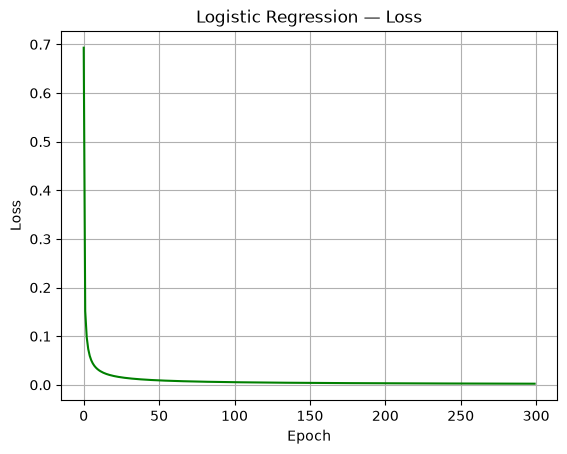

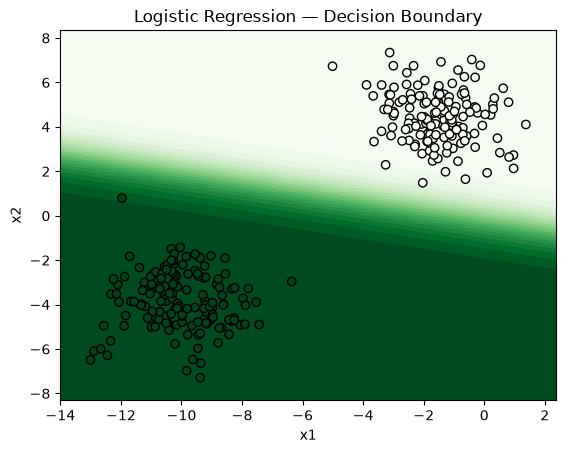

In [ ]:
# Logistic Regression
# Logistic Regression is a supervised learning algorithm used for binary classification, predicting the probability that
# a data point belongs to a specific class.



import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(1)

X, y = make_blobs(n_samples=300, centers=2, cluster_std=1.2)
w = np.zeros(X.shape[1])
b = 0.0
lr = 0.2
losses = []

def sigmoid(z): return 1 / (1 + np.exp(-z))

for _ in range(300):
    z = X.dot(w) + b
    p = sigmoid(z)
    loss = -(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)).mean()
    losses.append(loss)
    dw = X.T.dot(p - y) / len(X)
    db = (p - y).mean()
    w -= lr * dw
    b -= lr * db

plt.figure()
plt.plot(losses, color="green")
plt.title("Logistic Regression — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid.dot(w) + b).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, probs, 20, cmap="Greens")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Greens", edgecolor="black")
plt.title("Logistic Regression — Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

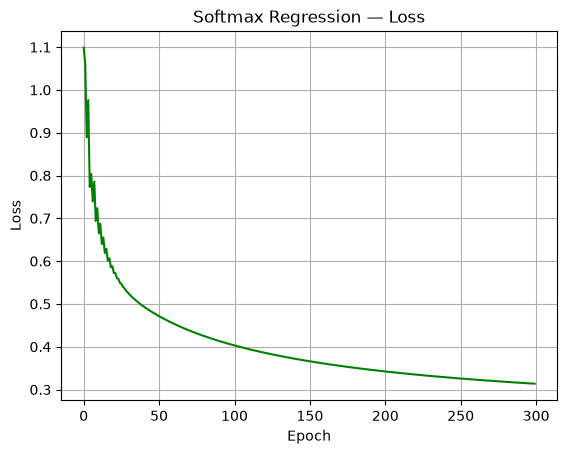

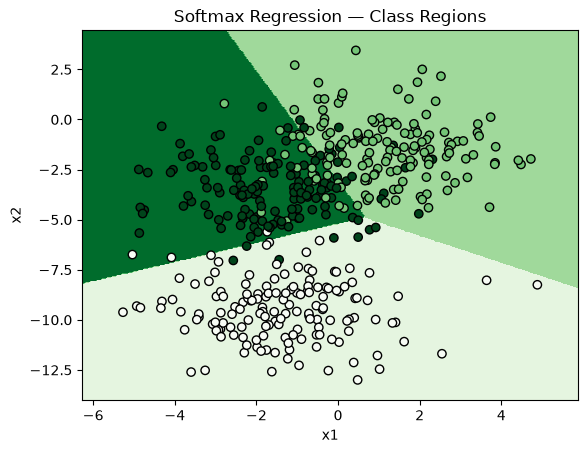

In [3]:
#  Softmax Regression

# Softmax Regression is an extension of logistic regression used for multi-class classification, predicting probabilities
# across multiple classes.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(2)

X, y = make_blobs(n_samples=450, centers=3, cluster_std=1.5)
K = 3

W = np.zeros((X.shape[1], K))
b = np.zeros(K)
lr = 0.2
epochs = 300
losses = []

def softmax(z):
    z -= z.max(axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / expz.sum(axis=1, keepdims=True)

for _ in range(epochs):
    logits = X.dot(W)+b
    probs = softmax(logits)
    Y = np.zeros_like(probs); Y[np.arange(len(y)), y] = 1
    loss = -np.sum(Y*np.log(probs+1e-12))/len(X)
    losses.append(loss)
    dW = X.T.dot(probs-Y)/len(X)
    db = (probs-Y).mean(axis=0)
    W -= lr*dW
    b -= lr*db

plt.figure()
plt.plot(losses, color="green")
plt.title("Softmax Regression — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
preds = np.argmax(softmax(grid.dot(W)+b), axis=1).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, preds, K, cmap="Greens")
plt.scatter(X[:,0], X[:,1], c=y, cmap="Greens", edgecolor="black")
plt.title("Softmax Regression — Class Regions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()



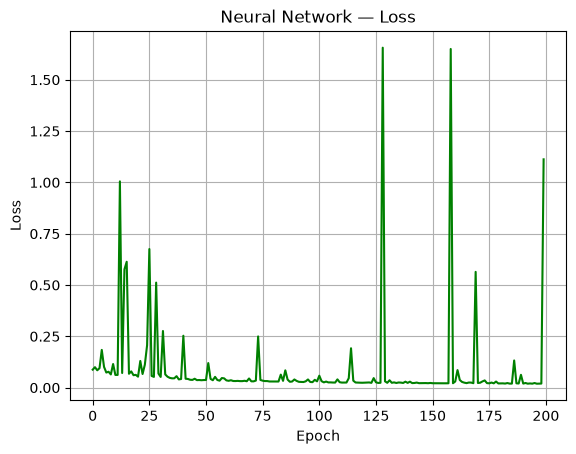

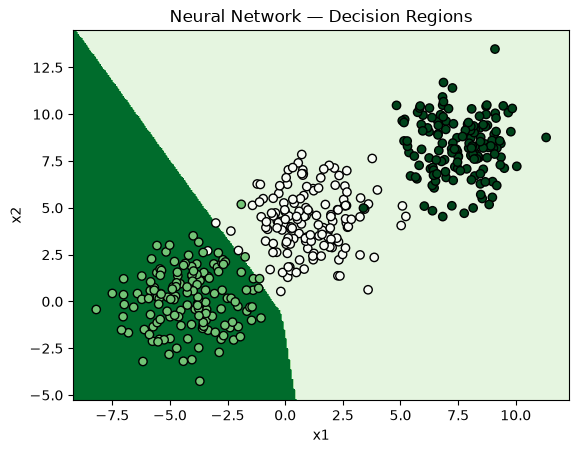

In [4]:
# Neural Network

# A neural network with one hidden layer can learn complex patterns that linear models cannot capture by introducing non-linearity
# through activation functions.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(3)

X, y = make_blobs(n_samples=450, centers=3, cluster_std=1.5)
K = 3
D = X.shape[1]
H = 32

W1 = np.random.randn(D, H) * np.sqrt(2 / D)
b1 = np.zeros(H)
W2 = np.random.randn(H, K) * np.sqrt(2 / H)
b2 = np.zeros(K)

lr = 0.05
epochs = 200
batch = 64
losses = []

relu = lambda z: np.maximum(0, z)

def softmax(z):
    z -= z.max(axis=1, keepdims=True)
    expz = np.exp(z)
    return expz / expz.sum(axis=1, keepdims=True)

for _ in range(epochs):
    idx = np.random.permutation(len(X))
    Xs, Ys = X[idx], y[idx]
    for i in range(0, len(Xs), batch):
        xb = Xs[i:i + batch]
        yb = Ys[i:i + batch]
        z1 = xb.dot(W1) + b1
        a1 = relu(z1)
        logits = a1.dot(W2) + b2
        probs = softmax(logits)
        Yb = np.zeros_like(probs)
        Yb[np.arange(len(yb)), yb] = 1
        dlog = (probs - Yb) / len(yb)
        dW2 = a1.T.dot(dlog)
        db2 = dlog.sum(axis=0)
        da1 = dlog.dot(W2.T)
        dz1 = da1 * (z1 > 0)
        dW1 = xb.T.dot(dz1)
        db1 = dz1.sum(axis=0)
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    logits_full = relu(X.dot(W1) + b1).dot(W2) + b2
    pf = softmax(logits_full)
    Yf = np.zeros_like(pf)
    Yf[np.arange(len(y)), y] = 1
    losses.append(-(Yf * np.log(pf + 1e-12)).mean())

plt.figure()
plt.plot(losses, color="green")
plt.title("Neural Network — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
pred = np.argmax(softmax(relu(grid.dot(W1) + b1).dot(W2) + b2),
                 axis=1).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, pred, K, cmap="Greens")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Greens", edgecolor="black")
plt.title("Neural Network — Decision Regions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

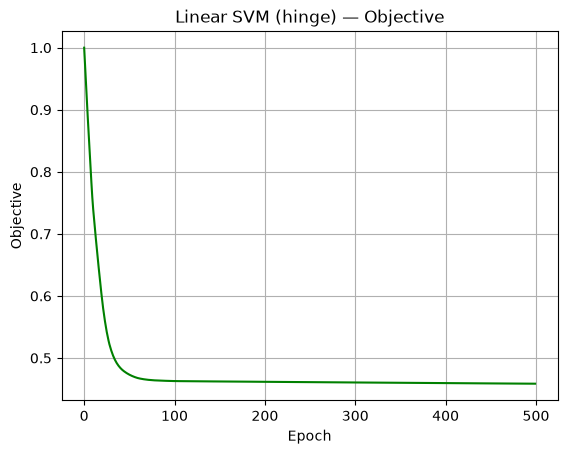

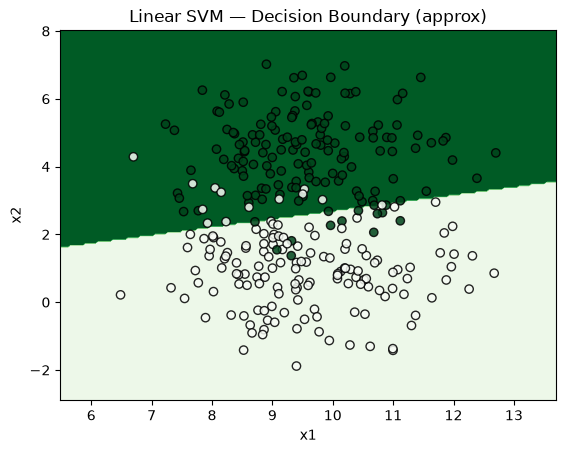

In [5]:
# Support Vector Machine

# A Support Vector Machine is a supervised learning algorithm used for classification and regression that finds the best boundary
# to separate data points.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(4)

X, y_binary = make_blobs(n_samples=300, centers=2, cluster_std=1.2)
y = 2 * y_binary - 1

w = np.zeros(X.shape[1])
b = 0.0
lr = 0.01
C = 1.0
epochs = 500
losses = []

for _ in range(epochs):
    margins = y * (X.dot(w) + b)
    hinge = np.maximum(0, 1 - margins)
    loss = 0.5 * np.dot(w, w) + C * hinge.mean()
    losses.append(loss)
    mask = margins < 1
    if mask.any():
        dw = w - (C / len(X)) * X[mask].T.dot(y[mask])
        db = -(C / len(X)) * y[mask].sum()
    else:
        dw = w
        db = 0.0
    w -= lr * dw
    b -= lr * db

plt.figure()
plt.plot(losses, color="green")
plt.title("Linear SVM (hinge) — Objective")
plt.xlabel("Epoch")
plt.ylabel("Objective")
plt.grid(True)
plt.show()

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]
scores = grid.dot(w) + b

plt.figure()
plt.contourf(xx, yy, (scores.reshape(xx.shape) > 0).astype(int), cmap="Greens")
plt.scatter(X[:, 0], X[:, 1], c=y_binary, cmap="Greens",
            edgecolor="black", alpha=0.85)
plt.title("Linear SVM — Decision Boundary (approx)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


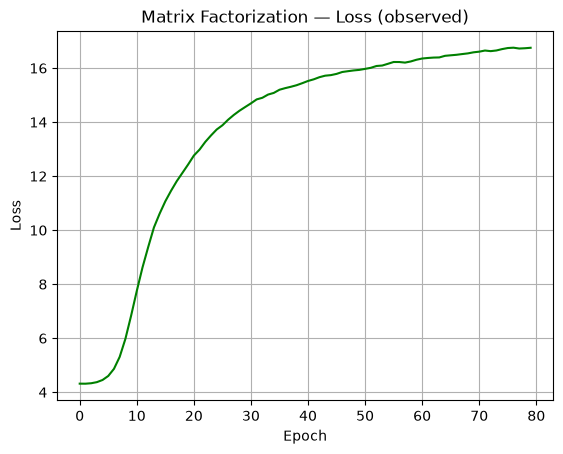

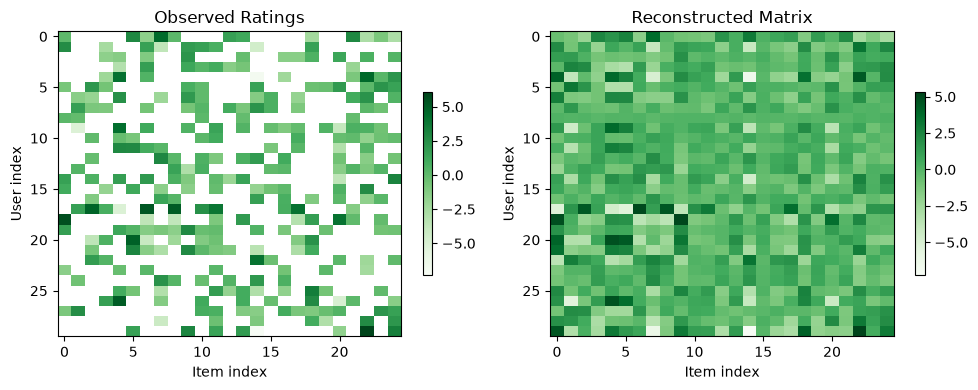

In [6]:
# Matrix Factorization

# Matrix Factorization is used in recommender systems to find hidden patterns in user item ratings.
# It breaks the rating matrix into smaller latent factors representing user preferences and item features,
# which are used to predict missing ratings.

import numpy as np
import matplotlib.pyplot as plt
np.random.seed(5)

n_users, n_items = 30, 25
true_k = 4
P_true = np.random.randn(n_users, true_k)
Q_true = np.random.randn(n_items, true_k)
R_full = P_true.dot(Q_true.T)

mask = np.random.rand(n_users, n_items) < 0.4
R = np.where(mask, R_full + 0.5 * np.random.randn(n_users, n_items), 0.0)

k = 4
P = 0.1 * np.random.randn(n_users, k)
Q = 0.1 * np.random.randn(n_items, k)
lr = 0.01
epochs = 80
reg = 0.1
losses = []

obs = np.argwhere(mask)
for _ in range(epochs):
    np.random.shuffle(obs)
    for i, j in obs:
        pred = P[i].dot(Q[j])
        err = R[i, j] - pred
        dP = -2 * err * Q[j] + 2 * reg * P[i]
        dQ = -2 * err * P[i] + 2 * reg * Q[j]
        P[i] -= lr * dP
        Q[j] -= lr * dQ
    pred_all = P.dot(Q.T)
    diff = mask * (R - pred_all)
    loss = (diff**2).sum() / mask.sum() + reg * (np.sum(P**2) + np.sum(Q**2))
    losses.append(loss)

plt.figure()
plt.plot(losses, color="green")
plt.title("Matrix Factorization — Loss (observed)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

recon = P.dot(Q.T)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(np.where(mask, R, np.nan), aspect='auto', cmap="Greens")
plt.title("Observed Ratings")
plt.xlabel("Item index")
plt.ylabel("User index")
plt.colorbar(shrink=0.6)

plt.subplot(1, 2, 2)
plt.imshow(recon, aspect='auto', cmap="Greens")
plt.title("Reconstructed Matrix")
plt.xlabel("Item index")
plt.ylabel("User index")
plt.colorbar(shrink=0.6)

plt.tight_layout()
plt.show()

